In [1]:
from cr_element import CRElement
from cr_gamestate import CRGameState
from cr_dataset import CRDataset

cr_dataset = CRDataset()
replay = cr_dataset.load_replay("arena_28/5cf7a760-d2ae-47e3-baad-172eb65a1d7b")

arena_28/5cf7a760-d2ae-47e3-baad-172eb65a1d7b
C:\Users\0dps1\.cache\huggingface\hub\datasets--chrisrca--clash-royale-tv-replays\snapshots\c5f66994ea749dcadb0471ab11de08cb90ed1d15\arena_28\5cf7a760-d2ae-47e3-baad-172eb65a1d7b\frames.parquet


arrows 3


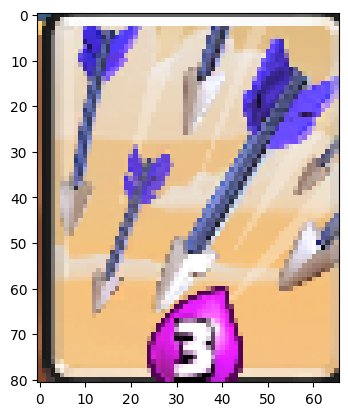

In [2]:
import matplotlib.pyplot as plt
print(cr_dataset.cards[0].name, cr_dataset.cards[0].cost)
plt.imshow(cr_dataset.cards[0].BGR)

In [3]:
import uuid

def check_exists_add_otherwise(library, newimage, frame, template_threshold, shearing = (3,3)):   
    if CRElement.is_grayscale(newimage) or CRGameState.is_card_selected(newimage):
        return

    # object: prepped image, original image, view count, timestamp, new_flag
    # library: hash: (object)
    if(len(library) == 0):
        library[str(uuid.uuid4())] = [CRElement.prep(newimage, 4), newimage, 1, frame]
        return
    labelled_image_collection = [(key, obj[0]) for key, obj in library.items()]
    best_score, best_match = CRElement.best_match(CRElement.prep(newimage, 4), labelled_image_collection, shearing=shearing)
    
    if best_score > template_threshold:
        library[best_match][2] = library[best_match][2] + 1
    else:
        library[str(uuid.uuid4())] = [CRElement.prep(newimage, 4), newimage, 1, frame]


Use this to find new cards in video

In [ ]:
# Go thru video and print all unique segments
import os
import cv2


def is_persistent(obj, time, override_window = False):
    count = obj[2]
    
    if(override_window):
        return count > 5
    
    age = time - obj[3]

    in_window = 50 < age < 150
    keep = count > 5 or not in_window
    return keep

def find_cards_in_video(replay):

    seen_images = {}

    for i, frame in enumerate(replay):
        if(i % 5 != 0): continue
        image = frame
        for card in CRElement.get_images_in_hand(image):
            check_exists_add_otherwise(seen_images, card, i, template_threshold=0.95)

        if i % 100 == 0 and i > 11 :
            seen_images = {key: value for key, value in seen_images.items() if is_persistent(value, i)}
            print(f"{i}, {len(seen_images)}")
    seen_images = {key: value for key, value in seen_images.items() if is_persistent(value, i, True)}

    for name, obj in seen_images.items():
        image = obj[1]
        labelled_image_collection = [(card.name, CRElement.prep(card.BGR)) for card in cr_dataset.cards]
        best_score, _ = CRElement.best_match(CRElement.prep(image), labelled_image_collection, shearing=(3,3))
        if(best_score < 0.95):
            os.makedirs("potential_new_cards/", exist_ok=True)
            cv2.imwrite(f"potential_new_cards/{name}.png", image)
            cr_dataset.cards.append(CRElement.Card(image=image, name=name))


find_cards_in_video(replay)

100, 5
200, 8
300, 8
400, 10
500, 10


In [ ]:
# TODO check potential new cards against existing database
# if no match, add to db
# move on to next replay
# Clear this path: C:\Users\0dps1\.cache\huggingface\hub\datasets--chrisrca--clash-royale-tv-replays\snapshots
# Clear this path: C:\Users\0dps1\.cache\huggingface\hub\datasets--chrisrca--clash-royale-tv-replays\blobs

manifest = [{"replay": "blah blah", "cards_identified": False}]

for replay in replays:
    # Check if replay in manifest and cards_identified
    
    replay = get_images_from_table(get_table_from_db("arena_28/5cf7a760-d2ae-47e3-baad-172eb65a1d7b"))
    find_cards_in_video(replay)
    existing_cards = load_all_cards()
    
    # Move unmatched cards to cards

In [24]:
os.listdir("elixir/")


['0.png',
 '1.png',
 '10.png',
 '2.png',
 '3.png',
 '4.png',
 '5.png',
 '6.png',
 '7.png',
 '8.png',
 '9.png']

In [ ]:
h0, w0 = replay[0].shape[:2]
writer = cv2.VideoWriter("annotated.mp4", 0, 10, (w0, h0), isColor=True)
old_hand = [None, None, None, None]
prev_elixir = 0
queued_elixir_losses = 0
played = []

for frame_num, frame in enumerate(replay):
    img = get_frame(frame)
    elixir = current_elixir(img, elixirs)
    if elixir is not None:
        if(elixir - prev_elixir < -0.8): queued_elixir_losses += 1
        prev_elixir = elixir

    my_hand = cards_in_hand(img, deck, elixir)
    empties = [index for index, element in enumerate(my_hand) if element == "empty-10.png"]
    nones = [index for index, element in enumerate(my_hand) if element is None]
    new_played = 0
    if(len(empties) > 0):
        for empty_index in empties:
            if old_hand[empty_index] != "empty-10.png":
                played.append(old_hand[empty_index])
                print(frame_num, old_hand[empty_index])
                new_played += 1
                old_hand[empty_index] = "empty-10.png"
                # print(empty_index)
    
    for i, card in enumerate(my_hand):
        if len(nones) > 0 or len(empties) > 0:
            continue
        gray = "gray" in card
        gray_old = old_hand[i] is not None and "gray" in old_hand[i]
        name = card.split('.')[0]
        if(old_hand[i] != name):
            if(queued_elixir_losses > 0 and old_hand[i] is not None and "gray_" + name != old_hand[i] and "gray_" + old_hand[i] != name):
                # if(gray or gray_old): continue

                played.append(old_hand[i])
                print(frame_num, old_hand[i])
                new_played += 1
                # print(old_hand, my_hand)
                # print(f"Played {old_hand[i]} replaced by {name}")
            old_hand[i] = name
        cv2.putText(img, name, (card_origin[0] + i * (card_space + card_size[0]), card_origin[1]- i * 8), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,255,0) if not gray else (255, 255, 255), 2)
    # TODO if empty appears, there is likely occlusion. Report card that empty replaced as played, but wait to update old hand.
    queued_elixir_losses -= new_played
    if (queued_elixir_losses < 0): queued_elixir_losses = 0
    cv2.putText(img, str(queued_elixir_losses), (40, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 5)
    for i, card in enumerate(played):
        if(card == "empty-10.png"): continue
        cv2.putText(img, card, (0, (i + 1) * 30), cv2.FONT_HERSHEY_SIMPLEX, 2, (255,0,255), 2)

    # If we lost 1 card and elixir went down that much (or that much - 1 if played before elixir addition (how to deal with elixir generators?)),
    # Count it as played
    # Update old_hand
    
    cv2.putText(img, str(elixir), (elixir_origin[0], elixir_origin[1]), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
    writer.write(img)

writer.release()
    

33 None
45 empty-10.png
46 gray_bomb_tower-4
61 gray_skele_barrel-3
61 gray_skele_barrel-3
61 gray_vines-3
61 gray_vines-3
168 gray_vines-3
223 gray_empty-10
223 empty-10.png
223 gray_vines-3
255 gray_empty-10
255 gray_vines-3
285 gray_skele_barrel-3
285 gray_empty-10
285 gray_barb_barrel-2
285 gray_dart_goblin-3
456 gray_vines-3
456 gray_empty-10
456 gray_barb_barrel-2
456 gray_dart_goblin-3
457 gray_barb_barrel-2
457 gray_empty-10
514 gray_skele_barrel-3
524 empty-10.png
524 gray_vines-3
524 gray_dart_goblin-3
527 gray_evo_ghost-3


In [ ]:
# TODO: Find matches that aren't in manifest.json
# Go through match once and find what cards are in deck (simply keep indices)
# Pre-compute clipped and grayscale of cards
# Find playtime of cards
# Check cards for best match. If match, write name and playtime to manifest. Otherwise, choose new card name first, then write to manifest
# For full automation, need to determine elixir cost when card found